# Labeled Data

Explore how to work with labeled data in machine learning by separating datasets according to class labels using scikit-learn. Learn to implement functions that categorize principal component data by class for effective data visualization and classification tasks.

**Chapter Goals:**

* Learn about labeled datasets.
* Separate principle component data by class label.

---

## Class labels

A big part of data science is classifying observations in a dataset into separate categories, or *classes*. A popular use case of data classification is in separating a dataset into "good" and "bad" categories. For example, we can classify a dataset of breast tumors as either malignant or benign.

The code below separates a breast cancer dataset into malignant and benign categories. The [`load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer) function is part of the scikit-learn library, and its data comes from the [Breast Cancer Wisconsin](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+\(Diagnostic\)) dataset.

```python
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
print('{}\n'.format(repr(bc.data)))
print('Data shape: {}\n'.format(bc.data.shape))

# Class labels
print('{}\n'.format(repr(bc.target)))
print('Labels shape: {}\n'.format(bc.target.shape))

# Label names
print('{}\n'.format(list(bc.target_names)))

malignant = bc.data[bc.target == 0]
print('Malignant shape: {}\n'.format(malignant.shape))

benign = bc.data[bc.target == 1]
print('Benign shape: {}\n'.format(benign.shape))
```

In the example above, the `bc.data` array contains all the dataset values, while the `bc.target` array contains the class ID labels for each row in `bc.data`. A class ID of `0` corresponds to a malignant tumor, while a class ID of `1` corresponds to a benign tumor.

Using the `bc.target` class IDs, we separated the dataset into malignant and benign data arrays. In other words, the `malignant` array contains the rows of `bc.data` corresponding to the indexes in `bc.target` containing `0`, while the `benign` array contains the rows of `bc.data` corresponding to the indexes in `bc.target` containing `1`. There are `212` malignant data observations and `357` benign observations.

---

## Time to Code!

1. The coding exercise in this chapter involves completing the `separate_components` function, which will separate principal component data by class.
2. To do this, we first need to complete a helper function, `get_label_info`, which returns the label name and data for an input class label.
3. The `component_data` input represents the principal component data.
4. The `labels` input is a 1-D array containing the class label IDs corresponding to each row of `component_data`. We can use it to separate the principle components by class.
5. The `class_label` input represents a particular class label ID.
6. The `label_names` input represents all the string names for the class labels.
7. Set `label_name` equal to the string at index `class_label` of `label_names`.
8. Set `label_data` equal to the rows of `component_data` corresponding to the indexes where `labels` equals `class_label`. Then return the tuple `(label_name, label_data)`.

9. Now, inside the main `separate_data` function, we'll iterate through each label in the `label_names` list.
10. Set `separated_data` equal to an empty list.
11. Create a `for` loop that iterates variable `class_label` through `range(len(label_names))`.
12. Inside the `for` loop, we can use our helper function to obtain the separated data for each class.
13. Inside the `for` loop, call `get_label_info` with inputs `component_data`, `labels`, `class_label`, and `label_names`. Append the function’s output to `separated_data`.
14. After finalizing the list of principle components separated by class, we return it.
15. Outside the `for` loop, return `separated_data`.

The `separate_data` function is incredibly useful for visualizing the components. We can use matplotlib to create nice plots of the separated data (shown in the code below).

In [1]:
def get_label_info(component_data, labels, class_label, label_names):
    label_name = label_names[class_label]
    label_data = component_data[labels == class_label]

    return label_name, label_data


def separate_data(component_data, labels, label_names):
    separated_data = []

    for class_label in range(len(label_names)):
        separated_data.append(
            get_label_info(component_data, labels, class_label, label_names)
        )

    return separated_data

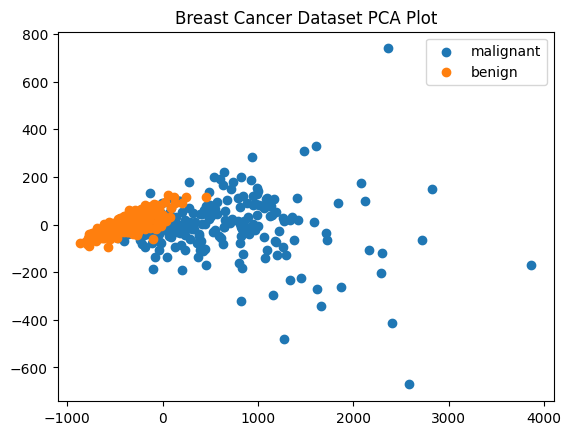

In [ ]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA

bc = load_breast_cancer()
pca_obj = PCA(n_components=2)
component_data = pca_obj.fit_transform(bc.data)
labels = bc.target
label_names = bc.target_names
# Using the completed separate_data function
separated_data = separate_data(component_data, labels, label_names)

# Plotting the data
for label_name, label_data in separated_data:
    col1 = label_data[:, 0]  # 1st column (1st pr. comp.)
    col2 = label_data[:, 1]  # 2nd column (2nd pr. comp.)
    plt.scatter(col1, col2, label=label_name)  # scatterplot
plt.legend()  # adds legend to plot
plt.title("Breast Cancer Dataset PCA Plot")
plt.show()
